In [3]:

import sys
from pathlib import Path

root_dir = Path().absolute().parent

sys.path.insert(0, str(root_dir))
from tqdm import tqdm
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib
from matplotlib import patches
from utils import utils
from PIL import Image
from collections import defaultdict
from scipy.signal import find_peaks

# np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
font = {"family": "Ubuntu", "size": 22}
matplotlib.rc("font", **font)
import json
from datetime import datetime
import argparse
from typing import List, Any

from multiprocessing.pool import ThreadPool
from multiprocessing import cpu_count


findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not

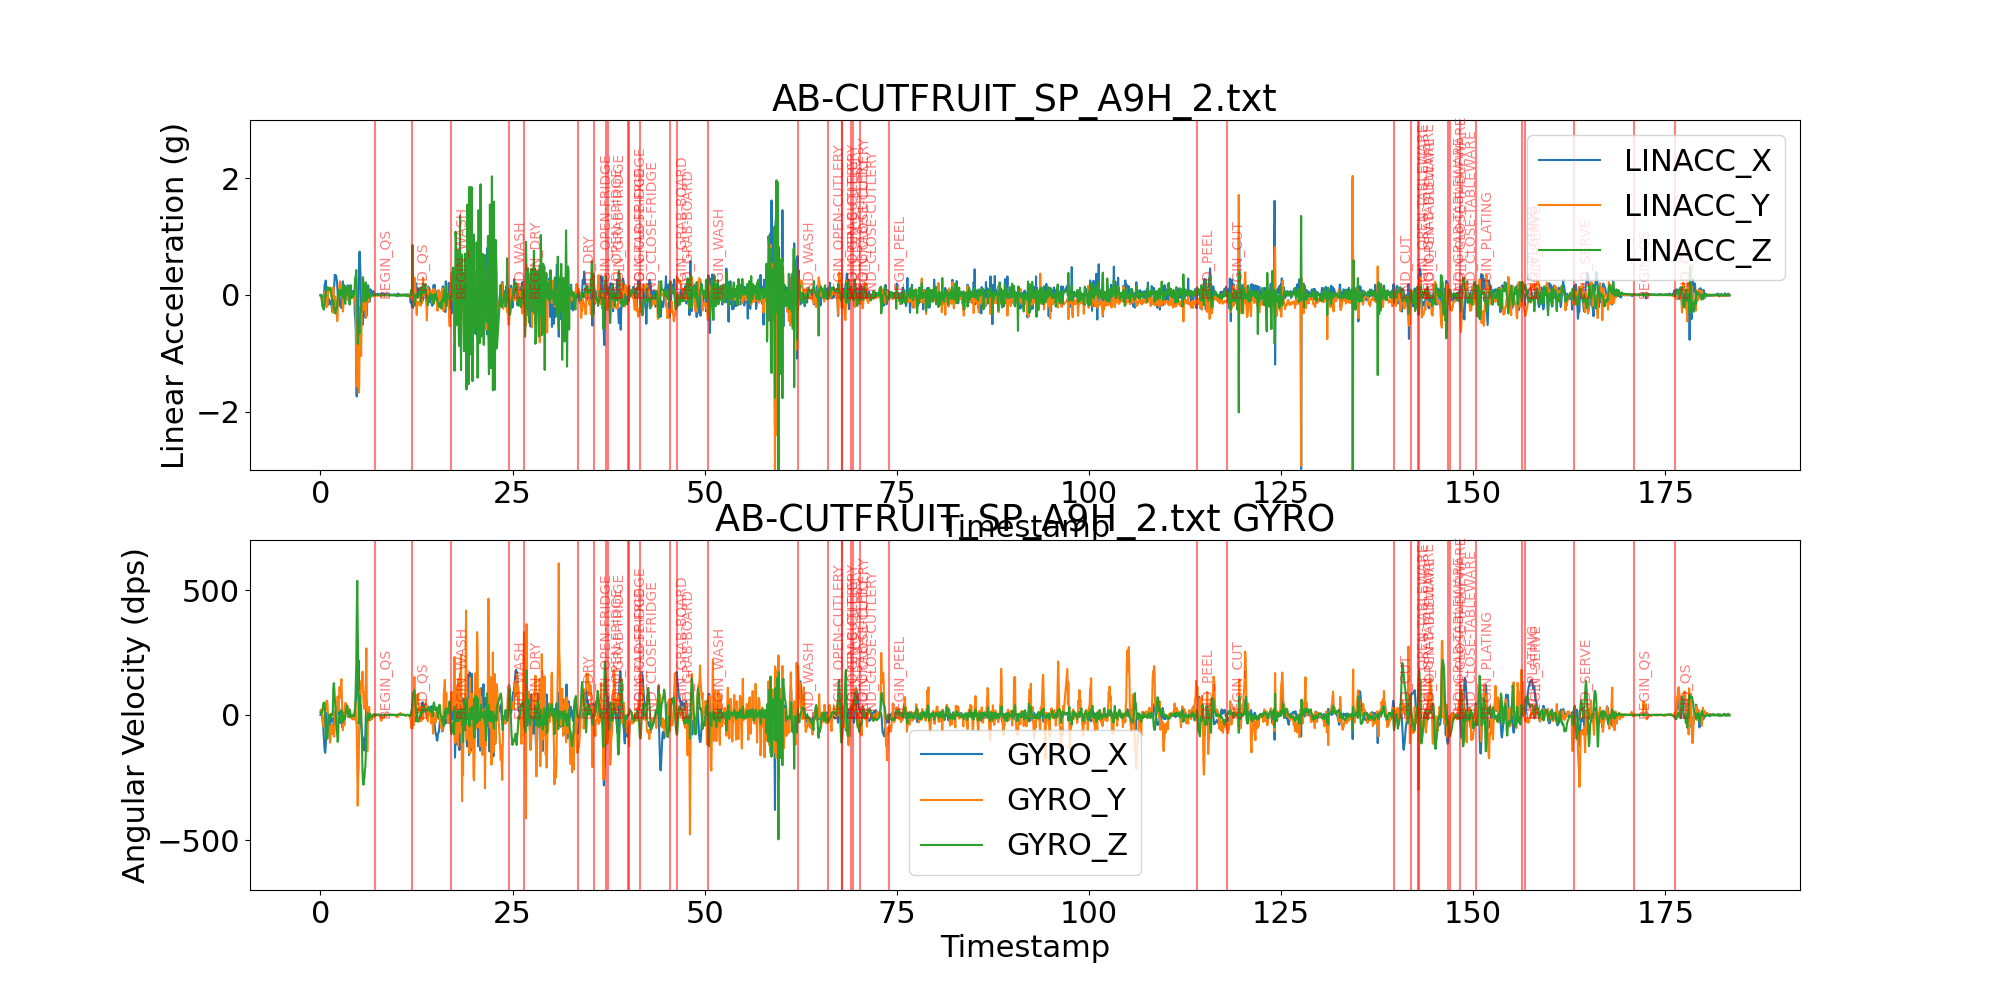

findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not

In [ ]:
%matplotlib widget

# MARK: - Config
##################################################
labels_dir = "03_Labels"
data_dir = "02_Pozyx_Positioning_Data"
regions_fp = Path().joinpath("outputs", "REGIONS", "2023-03-14 12:15:31.794149.json")
NUM_NORM_POINTS = 300
ANCHORS = "9H"
SUBJECT_INITIALS = "SP"
TYPE = "AB-CUTFRUIT"
TAG_ID =  "0x682f"
TRIAL = 2
##################################################

label_fn = f"{TYPE}_{SUBJECT_INITIALS}_A{ANCHORS}_{TRIAL}.txt"
data_fn = f"{TYPE}_{SUBJECT_INITIALS}_A{ANCHORS}_{TRIAL}.csv"

label_fp = root_dir.joinpath('data', labels_dir, TYPE, label_fn)
data_fp = root_dir.joinpath('data', data_dir, TYPE, data_fn)

data = pd.read_csv(data_fp)
data.columns = ['Timestamp', 'POS_X', 'POS_Y', 'POS_Z', 'Heading', 'Roll', 'Pitch', 'ACC_X', 'ACC_Y', 'ACC_Z','LINACC_X', 'LINACC_Y', 'LINACC_Z', 'GYRO_X', 'GYRO_Y', 'GYRO_Z', 'Pressure', 'TagId']
data = data.set_index('Timestamp')


data = data[data["TagId"] == TAG_ID]
data = data.drop("TagId", axis=1)

######################################################################
#  CLEANING DATA
######################################################################

cleaned_data = (data
                .loc[:, ['POS_X', 'POS_Y', 'POS_Z', 'LINACC_X', 'LINACC_Y', 'LINACC_Z', 'GYRO_X', 'GYRO_Y', 'GYRO_Z', 'Heading', 'Roll', 'Pitch']]
                # .pipe(utils.handle_spikes, ['POS_Z', 'POS_Y'], [1500.0, 800.0]) 
                .pipe(utils.MAV_cols, ['POS_X', 'POS_Y', 'POS_Z'], 20)
                # Acceleration is actually in mg
                .pipe(utils.apply_func, ['LINACC_X', 'LINACC_Y', 'LINACC_Z'], lambda x: x / 1000) 
                )
start_time = cleaned_data.index[0]

cleaned_data.index = cleaned_data.index - start_time

if label_fp.exists():                         
    labels = utils.extract_time_labels(label_fp)
    # Some preprocessing to align adding labels timestamp with video
    labels = [{'Timestamp': str(float(item['Timestamp']) - start_time), 'Label': item['Label']} for item in labels]


fig, (ax1, ax2) = plt.subplots(2,1, height_ratios=[1,1], figsize=(15,20))
ax = utils.plot_pozyx_data_with_timings(cleaned_data, ['LINACC_X','LINACC_Y', 'LINACC_Z'], labels, title=label_fp.name, ax=ax1, ylabel="Linear Acceleration (g)", ylim=(-3, 3))
ax2 = utils.plot_pozyx_data_with_timings(cleaned_data, ['GYRO_X','GYRO_Y','GYRO_Z'], labels, ylim=(-700, 700), ylabel="Angular Velocity (dps)", ax=ax2)
ax2.set_title(label_fn + " GYRO")
# ax2 = utils.plot_pozyx_data_with_timings(cleaned_data, ['Heading','Roll','Pitch'], labels, ylim=(-200, 360), ylabel="Orientation (deg)", ax=ax2)
# ax2.set_title(label_fn + " Orientation")

plt.show()